### Q1

In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import random
import requests

toy_text = (
    "hello world hello help hello hellish yellow mellow fellow "
    "bell sell tell well fell cell bell hello help helm held "
) * 40 

url = "https://www.gutenberg.org/files/11/11-0.txt"
real_text = requests.get(url).text[5000:55000]



In [36]:
TEXT = real_text

chars = sorted(list(set(TEXT)))
stoi = {ch:i for i,ch in enumerate(chars)}
itos = {i:ch for ch,i in stoi.items()}

vocab_size = len(chars)

encoded = [stoi[ch] for ch in TEXT]

print("Vocabulary:", chars)
print("Vocab size:", vocab_size)

seq_len = 20

X = []
Y = []

for i in range(len(encoded) - seq_len):
    X.append(encoded[i:i+seq_len])
    Y.append(encoded[i+1:i+seq_len+1])

X = torch.tensor(X)
Y = torch.tensor(Y)

split = int(0.8 * len(X))

X_train, X_val = X[:split], X[split:]
Y_train, Y_val = Y[:split], Y[split:]

Vocabulary: ['\n', ' ', '!', '(', ')', '*', ',', '-', '.', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'Y', '_', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'ù', '—', '‘', '’', '“', '”']
Vocab size: 69


In [37]:
# class to represent our rnn
class CharRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=16, hidden_size=128):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.GRU(embed_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
    
    def forward(self, x, hidden=None):
        x = self.embed(x)
        out, hidden = self.rnn(x, hidden)
        logits = self.fc(out)
        return logits, hidden

In [38]:
def generate(model, start_text="h", length=100, temperature=1.0):
    model.eval()
    
    # convert starting text to tensor
    input_seq = torch.tensor([[stoi[ch] for ch in start_text]], dtype=torch.long).to('cpu')
    
    generated = start_text
    hidden = None
    
    with torch.no_grad():
        # first pass through the seed text
        logits, hidden = model(input_seq, hidden)
        
        # get last character prediction
        last_logits = logits[:, -1, :] / temperature
        probs = torch.softmax(last_logits, dim=-1)
        
        next_idx = torch.multinomial(probs, 1).item()
        generated += itos[next_idx]
        
        # now generate one char at a time
        input_seq = torch.tensor([[next_idx]], dtype=torch.long).to('cpu')
        
        for _ in range(length - 1):
            logits, hidden = model(input_seq, hidden)
            
            last_logits = logits[:, -1, :] / temperature
            probs = torch.softmax(last_logits, dim=-1)
            
            next_idx = torch.multinomial(probs, 1).item()
            generated += itos[next_idx]
            
            input_seq = torch.tensor([[next_idx]], dtype=torch.long).to('cpu')
    
    return generated

In [ ]:
model = CharRNN(vocab_size).to('cpu')
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

batch_size = 16
epochs = 2

train_losses = []
val_losses = []

temps = [0.7, 1.0, 1.2]

# determines the number of times the model sees the training data
# I found that lowering this prevents overfitting
for epoch in range(epochs):
    model.train()
    total_train_loss = 0
    
    perm = torch.randperm(len(X_train))
    
    # For the number of pairs in our training data
    for i in range(0, len(X_train), batch_size):
        idx = perm[i:i+batch_size]
        xb = X_train[idx].to('cpu')
        yb = Y_train[idx].to('cpu')
        
        optimizer.zero_grad()
        
        logits, _ = model(xb)
        
        loss = criterion(
            logits.reshape(-1, vocab_size),
            yb.reshape(-1)
        )
        
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
    
    # Report the loss 
    train_loss = total_train_loss / (len(X_train) / batch_size)
    train_losses.append(train_loss)
    
    model.eval()
    with torch.no_grad():
        logits, _ = model(X_val.to('cpu'))
        val_loss = criterion(
            logits.reshape(-1, vocab_size),
            Y_val.to('cpu').reshape(-1)
        ).item()
    
    val_losses.append(val_loss)
    
    print(f"\nEpoch {epoch+1}: train={train_loss:.4f}, val={val_loss:.4f}")
    
    # generate a sample with the model that just got trained.
    for temp in temps:
        sample = generate(model, length=100, temperature=temp)
        print(f"\nTemp={temp}")
        print(sample)


Epoch 1: train=1.6713, val=1.9516

Temp=0.7
he beforead poor Alice time was got age with one firent was got me away, as catcece it such a grewhet

Temp=1.0
he happen: for of caimoused happ a pointed at bling oung it handed on geeting of hings dife to gethe 

Temp=1.2
hn, will; the fiboroking lice was come a like a little down it curned itsencu! it was was not, will y

Epoch 2: train=1.6646, val=2.0673

Temp=0.7
he insene, and soon here brris the half to be of
at here to go sure it she head—Nut on in a or the ha

Temp=1.0
he oonce—a
shetht like the how the yet, you wele the
wond with on you was—Bhut you happ tayou! the co

Temp=1.2
his, you, thing Foows enep in was giep heam

“Ufer—I’t’s like of dour,” ”
Buthonn a popeageid gocdets


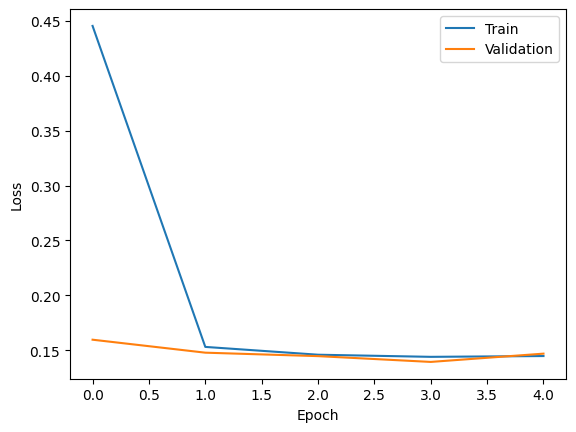

In [ ]:
# Plots training loss
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Increasing the hidden size maskes the model more flexible and complex, but it caused the model to overfit a bit. Increasing sequence length gives the model
more context but training takes much longer. As can be seen above, a higher temperature gives the model too much freedom to generate whatever token it wants.
This results in mostly nonsense being generated for temp=1.2.